## Obiettivo
Costruire una rappresentazione **acustica e interpretabile** del modo di parlare
del paziente **senza utilizzare DN4, BPI o NRS** durante l'estrazione delle feature.
La pipeline è:
**diarizzazione + ruoli revisionati → turni reali del paziente → feature acustiche → profilo per paziente**
Le associazioni con gli score clinici verranno effettuate soltanto nei notebook
successivi.

Il notebook riprende le principali famiglie di feature:
- F0 / pitch;
- RMS / energia;
- pause e attività vocale;
- MFCC;
- spectral centroid, rolloff, bandwidth, flatness, contrast;
- zero crossing rate;
- HNR;
- jitter;
- shimmer.

Vengono però introdotte alcune modifiche metodologiche:
1. non vengono utilizzate le finestre fisse da 10 s, ma i **turni effettivi del paziente**;
2. i tempi rimangono riferiti alla **timeline originale**, senza concatenare artificialmente i turni;
3. la variabile che nel lavoro precedente era denominata `speaking_rate` viene qui
   chiamata correttamente **speech activity ratio**, perché misura la quota di tempo
   non silenzioso e non il numero di parole/sillabe al secondo;
4. le pause interne vengono separate dal semplice silenzio ai bordi del turno;
5. viene calcolata, quando possibile, anche la **latenza di risposta** dopo un turno
   di `medico_altro`;
6. DN4/BPI/NRS sono intenzionalmente assenti dagli output di questa fase.

## Nota sui turni molto brevi
Viene scelta una soglia
più prudente di **0.5 s** per l'analisi acustica, perché misure come F0, jitter e
shimmer diventano instabili su segmenti estremamente brevi.

I turni più brevi non vengono cancellati dalla timeline: vengono documentati nel
controllo qualità, ma non usati per il vettore acustico principale.


## 0. Dipendenze

In [2]:
%pip install -q librosa praat-parselmouth soundfile scipy

Note: you may need to restart the kernel to use updated packages.


Impossibile trovare il percorso specificato.


## 1. Setup e percorsi

In [ ]:

from pathlib import Path
import math
import re
import json
import warnings

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

import librosa
import parselmouth

from parselmouth.praat import call
from scipy.signal import resample_poly

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd()

if not (PROJECT_DIR / "risultati").exists():
    fallback = Path(r"C:\Users\acer\Desktop\ProgettoTesi")
    if fallback.exists():
        PROJECT_DIR = fallback

AUDIO_DIR = PROJECT_DIR / "file_wav"
RESULTS_DIR = PROJECT_DIR / "risultati"

DIAR_DIR = (
    RESULTS_DIR
    / "diarizzazione_batch"
    / "completo"
)

SELECTION_DIR = (
    RESULTS_DIR
    / "selezione_canale"
)

ROLES_CSV = (
    SELECTION_DIR
    / "mappa_ruoli_speaker_finale_semplificata.csv"
)

CHANNEL_CSV = (
    SELECTION_DIR
    / "canale_scelto_per_registrazione.csv"
)

OUTPUT_DIR = (
    RESULTS_DIR
    / "feature_acustiche_paziente"
)

TURN_AUDIO_DIR = (
    OUTPUT_DIR
    / "turni_audio"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TURN_AUDIO_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# Configurazione
# ------------------------------------------------------------

TARGET_SR = 16_000

# Turni più brevi rimangono documentati ma non vengono
# utilizzati per l'estrazione acustica completa.
MIN_TURN_DURATION = 0.50

# Gap massimo usato soltanto per ricomporre frammentazioni
# adiacenti della diarizzazione attribuite al paziente.
MERGE_GAP_SECONDS = 0.25

# Pausa interna minima considerata come pausa.
MIN_INTERNAL_PAUSE_SECONDS = 0.15

# Stessa soglia usata nel lavoro di Genovese per
# librosa.effects.split.
SILENCE_TOP_DB = 20

# Range F0 coerente con il lavoro di Genovese.
F0_MIN = 75
F0_MAX = 300

EXPORT_TURN_AUDIO = True

print("PROJECT_DIR:", PROJECT_DIR)
print("AUDIO_DIR:", AUDIO_DIR)
print("DIAR_DIR:", DIAR_DIR)
print("ROLES_CSV:", ROLES_CSV)
print("CHANNEL_CSV:", CHANNEL_CSV)
print("OUTPUT_DIR:", OUTPUT_DIR)

for path in [
    AUDIO_DIR,
    DIAR_DIR,
    ROLES_CSV,
    CHANNEL_CSV,
]:
    print(path, "->", path.exists())

if not AUDIO_DIR.exists():
    raise FileNotFoundError(AUDIO_DIR)

if not DIAR_DIR.exists():
    raise FileNotFoundError(DIAR_DIR)

if not ROLES_CSV.exists():
    raise FileNotFoundError(ROLES_CSV)

if not CHANNEL_CSV.exists():
    raise FileNotFoundError(CHANNEL_CSV)


PROJECT_DIR: c:\Users\acer\Desktop\ProgettoTesi
AUDIO_DIR: c:\Users\acer\Desktop\ProgettoTesi\file_wav
DIAR_DIR: c:\Users\acer\Desktop\ProgettoTesi\risultati\diarizzazione_batch\completo
ROLES_CSV: c:\Users\acer\Desktop\ProgettoTesi\risultati\selezione_canale\mappa_ruoli_speaker_finale_semplificata.csv
CHANNEL_CSV: c:\Users\acer\Desktop\ProgettoTesi\risultati\selezione_canale\canale_scelto_per_registrazione.csv
OUTPUT_DIR: c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente
c:\Users\acer\Desktop\ProgettoTesi\file_wav -> True
c:\Users\acer\Desktop\ProgettoTesi\risultati\diarizzazione_batch\completo -> True
c:\Users\acer\Desktop\ProgettoTesi\risultati\selezione_canale\mappa_ruoli_speaker_finale_semplificata.csv -> True
c:\Users\acer\Desktop\ProgettoTesi\risultati\selezione_canale\canale_scelto_per_registrazione.csv -> True


## 2. Caricamento ruoli e canali selezionati

In [ ]:

roles = pd.read_csv(ROLES_CSV)
channels = pd.read_csv(CHANNEL_CSV)

required_roles = {
    "recording_id",
    "canale",
    "speaker",
    "ruolo_semplificato",
}

missing_roles = (
    required_roles
    - set(roles.columns)
)

if missing_roles:
    raise ValueError(
        "Colonne mancanti nel file ruoli: "
        f"{sorted(missing_roles)}"
    )

required_channels = {
    "patient_id",
    "recording_id",
    "nome_file",
    "canale",
}

missing_channels = (
    required_channels
    - set(channels.columns)
)

if missing_channels:
    raise ValueError(
        "Colonne mancanti nel file canali: "
        f"{sorted(missing_channels)}"
    )

roles["recording_id"] = (
    roles["recording_id"]
    .astype(str)
)

roles["canale"] = (
    roles["canale"]
    .astype(str)
    .str.lower()
)

roles["speaker"] = (
    roles["speaker"]
    .astype(str)
)

roles["ruolo_semplificato"] = (
    roles["ruolo_semplificato"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

channels["recording_id"] = (
    channels["recording_id"]
    .astype(str)
)

channels["canale"] = (
    channels["canale"]
    .astype(str)
    .str.lower()
)

channels["patient_id"] = pd.to_numeric(
    channels["patient_id"],
    errors="coerce",
)

valid_recordings = sorted(
    roles["recording_id"].unique()
)

channels_valid = channels[
    channels["recording_id"].isin(
        valid_recordings
    )
].copy()

print("Registrazioni nel file ruoli:", roles["recording_id"].nunique())
print("Pazienti nei canali validi:", channels_valid["patient_id"].nunique())
print("Speaker totali:", len(roles))

print("\nDistribuzione ruoli:")
display(
    roles["ruolo_semplificato"]
    .value_counts(dropna=False)
    .rename("speaker")
    .to_frame()
)

recordings_without_patient = []

for recording_id, group in roles.groupby("recording_id"):
    if not (
        group["ruolo_semplificato"]
        == "paziente"
    ).any():
        recordings_without_patient.append(
            recording_id
        )

print(
    "Registrazioni senza speaker paziente:",
    len(recordings_without_patient),
)

if recordings_without_patient:
    display(recordings_without_patient)
    raise RuntimeError(
        "Esistono registrazioni valide senza ruolo paziente."
    )


Registrazioni nel file ruoli: 92
Pazienti nei canali validi: 90
Speaker totali: 195

Distribuzione ruoli:


,speaker
ruolo_semplificato,
medico_altro,99
paziente,96


Registrazioni senza speaker paziente: 0



## 3. Caricamento della diarizzazione del canale selezionato

Per ogni registrazione viene letto il CSV:

`risultati/diarizzazione_batch/completo/<recording_id>__<canale>.csv`

e ciascun segmento viene associato al ruolo manualmente revisionato.


In [3]:

diar_tables = []
missing_diar = []

for row in channels_valid.itertuples(index=False):
    recording_id = str(row.recording_id)
    canale = str(row.canale).lower()

    diar_path = (
        DIAR_DIR
        / f"{recording_id}__{canale}.csv"
    )

    if not diar_path.exists():
        missing_diar.append(
            str(diar_path)
        )
        continue

    df = pd.read_csv(
        diar_path
    )

    required = {
        "patient_id",
        "recording_id",
        "nome_file",
        "canale",
        "inizio_secondi",
        "fine_secondi",
        "speaker",
    }

    missing = (
        required
        - set(df.columns)
    )

    if missing:
        raise ValueError(
            f"{diar_path.name}: "
            f"colonne mancanti {sorted(missing)}"
        )

    df = df.copy()

    df["recording_id"] = (
        df["recording_id"]
        .astype(str)
    )

    df["canale"] = (
        df["canale"]
        .astype(str)
        .str.lower()
    )

    df["speaker"] = (
        df["speaker"]
        .astype(str)
    )

    diar_tables.append(df)

if missing_diar:
    print(
        "CSV diarizzazione mancanti:",
        len(missing_diar),
    )
    display(missing_diar[:20])

    raise FileNotFoundError(
        "Mancano alcuni CSV di diarizzazione."
    )

diar = pd.concat(
    diar_tables,
    ignore_index=True,
)

for col in [
    "patient_id",
    "inizio_secondi",
    "fine_secondi",
]:
    diar[col] = pd.to_numeric(
        diar[col],
        errors="coerce",
    )

diar = diar.dropna(
    subset=[
        "patient_id",
        "inizio_secondi",
        "fine_secondi",
        "speaker",
    ]
).copy()

diar = diar[
    diar["fine_secondi"]
    > diar["inizio_secondi"]
].copy()

role_small = roles[
    [
        "recording_id",
        "canale",
        "speaker",
        "ruolo_semplificato",
    ]
].drop_duplicates()

diar = diar.merge(
    role_small,
    on=[
        "recording_id",
        "canale",
        "speaker",
    ],
    how="left",
    validate="many_to_one",
)

missing_role_rows = (
    diar["ruolo_semplificato"]
    .isna()
)

print("Segmenti diarizzati:", len(diar))
print("Registrazioni:", diar["recording_id"].nunique())
print("Pazienti:", diar["patient_id"].nunique())
print("Segmenti senza ruolo:", int(missing_role_rows.sum()))

if missing_role_rows.any():
    display(
        diar.loc[
            missing_role_rows,
            [
                "recording_id",
                "canale",
                "speaker",
            ],
        ]
        .drop_duplicates()
        .head(30)
    )

    raise RuntimeError(
        "Alcuni segmenti di diarizzazione non hanno un ruolo."
    )

display(
    diar["ruolo_semplificato"]
    .value_counts()
    .rename("segmenti")
    .to_frame()
)


Segmenti diarizzati: 10040
Registrazioni: 92
Pazienti: 90
Segmenti senza ruolo: 0


,segmenti
ruolo_semplificato,
medico_altro,5133
paziente,4907


## 4. Ricostruzione dei turni del paziente

In [4]:

def overlaps_other_speech(
    full_group,
    start_gap,
    end_gap,
):
    if end_gap <= start_gap:
        return False

    other = full_group[
        (
            full_group["ruolo_semplificato"]
            != "paziente"
        )
        & (
            full_group["inizio_secondi"]
            < end_gap
        )
        & (
            full_group["fine_secondi"]
            > start_gap
        )
    ]

    return not other.empty


def build_patient_turns(full_group):
    full_group = (
        full_group
        .sort_values(
            [
                "inizio_secondi",
                "fine_secondi",
            ]
        )
        .reset_index(drop=True)
    )

    patient = full_group[
        full_group["ruolo_semplificato"]
        == "paziente"
    ].copy()

    if patient.empty:
        return []

    turns = []

    for row in patient.itertuples(index=False):
        start = float(row.inizio_secondi)
        end = float(row.fine_secondi)
        speaker = str(row.speaker)

        if not turns:
            turns.append({
                "start": start,
                "end": end,
                "patient_speakers": {speaker},
                "n_diar_segments": 1,
            })
            continue

        previous = turns[-1]
        gap = start - previous["end"]

        can_merge = (
            gap <= MERGE_GAP_SECONDS
            and not overlaps_other_speech(
                full_group,
                previous["end"],
                start,
            )
        )

        if can_merge:
            previous["end"] = max(
                previous["end"],
                end,
            )
            previous["patient_speakers"].add(
                speaker
            )
            previous["n_diar_segments"] += 1
        else:
            turns.append({
                "start": start,
                "end": end,
                "patient_speakers": {speaker},
                "n_diar_segments": 1,
            })

    # --------------------------------------------------------
    # Contesto temporale: ultimo segmento medico/altro
    # terminato prima dell'inizio del turno.
    # --------------------------------------------------------

    for turn in turns:
        before = full_group[
            full_group["fine_secondi"]
            <= turn["start"]
        ].sort_values(
            "fine_secondi"
        )

        response_latency = np.nan
        preceding_role = ""
        preceding_speaker = ""

        if not before.empty:
            prev = before.iloc[-1]

            preceding_role = str(
                prev["ruolo_semplificato"]
            )

            preceding_speaker = str(
                prev["speaker"]
            )

            if preceding_role == "medico_altro":
                response_latency = max(
                    0.0,
                    turn["start"]
                    - float(
                        prev["fine_secondi"]
                    ),
                )

        turn["preceding_role"] = preceding_role
        turn["preceding_speaker"] = preceding_speaker
        turn["response_latency_seconds"] = response_latency

    return turns


turn_rows = []

for recording_id, group in diar.groupby(
    "recording_id",
    sort=True,
):
    first = group.iloc[0]

    turns = build_patient_turns(
        group
    )

    for turn_index, turn in enumerate(
        turns
    ):
        duration = (
            turn["end"]
            - turn["start"]
        )

        turn_rows.append({
            "patient_id": int(first["patient_id"]),
            "recording_id": str(recording_id),
            "nome_file": str(first["nome_file"]),
            "canale": str(first["canale"]),
            "turn_index": turn_index,
            "turn_id": (
                f"{recording_id}"
                f"__patient_turn_{turn_index:04d}"
            ),
            "start_seconds": float(
                turn["start"]
            ),
            "end_seconds": float(
                turn["end"]
            ),
            "turn_duration_seconds": float(
                duration
            ),
            "patient_speakers": "|".join(
                sorted(
                    turn["patient_speakers"]
                )
            ),
            "n_diar_segments_merged": int(
                turn["n_diar_segments"]
            ),
            "preceding_role": (
                turn["preceding_role"]
            ),
            "preceding_speaker": (
                turn["preceding_speaker"]
            ),
            "response_latency_seconds": (
                turn[
                    "response_latency_seconds"
                ]
            ),
            "eligible_acoustic_analysis": (
                duration >= MIN_TURN_DURATION
            ),
        })

turns_df = pd.DataFrame(
    turn_rows
)

if turns_df.empty:
    raise RuntimeError(
        "Nessun turno paziente trovato."
    )

TURN_METADATA_CSV = (
    OUTPUT_DIR
    / "turni_paziente_metadata.csv"
)

turns_df.to_csv(
    TURN_METADATA_CSV,
    index=False,
)

print("Turni paziente totali:", len(turns_df))
print(
    "Turni >= 0.5 s:",
    int(
        turns_df[
            "eligible_acoustic_analysis"
        ].sum()
    ),
)
print(
    "Turni < 0.5 s:",
    int(
        (~turns_df[
            "eligible_acoustic_analysis"
        ]).sum()
    ),
)
print(
    "Registrazioni:",
    turns_df["recording_id"].nunique(),
)
print(
    "Pazienti:",
    turns_df["patient_id"].nunique(),
)

display(
    turns_df[
        "turn_duration_seconds"
    ].describe()
)

display(
    turns_df.groupby(
        "patient_id"
    )
    .size()
    .rename("numero_turni")
    .describe()
)

print("Salvato:", TURN_METADATA_CSV)


Turni paziente totali: 4625
Turni >= 0.5 s: 3825
Turni < 0.5 s: 800
Registrazioni: 92
Pazienti: 90


count    4625.000000
mean        2.462553
std         3.570338
min         0.016000
25%         0.675000
50%         1.300000
75%         2.785000
max        57.881000
Name: turn_duration_seconds, dtype: float64

count     90.000000
mean      51.388889
std       18.014784
min        9.000000
25%       41.250000
50%       47.500000
75%       59.750000
max      104.000000
Name: numero_turni, dtype: float64

Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\turni_paziente_metadata.csv


## 5. Funzioni audio e feature

In [5]:

def safe_name(text):
    text = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        str(text),
    )
    return text.strip("_")


def channel_index(
    channel,
    n_channels,
):
    channel = str(
        channel
    ).lower()

    if n_channels == 1:
        return 0

    if channel == "mono":
        return 0

    if channel == "sinistro":
        return 0

    if channel == "destro":
        if n_channels < 2:
            return 0
        return 1

    raise ValueError(
        f"Canale non riconosciuto: {channel}"
    )


def resample_audio(
    y,
    source_sr,
    target_sr,
):
    if source_sr == target_sr:
        return y.astype(
            np.float32,
            copy=False,
        )

    gcd = math.gcd(
        int(source_sr),
        int(target_sr),
    )

    up = target_sr // gcd
    down = source_sr // gcd

    return resample_poly(
        y,
        up,
        down,
    ).astype(np.float32)


def internal_pause_intervals(
    speaking_intervals,
    sr,
):
    pauses = []

    if len(speaking_intervals) < 2:
        return pauses

    for index in range(
        len(speaking_intervals) - 1
    ):
        start = int(
            speaking_intervals[index][1]
        )

        end = int(
            speaking_intervals[index + 1][0]
        )

        duration = (
            end - start
        ) / sr

        if (
            end > start
            and duration
            >= MIN_INTERNAL_PAUSE_SECONDS
        ):
            pauses.append(
                (
                    start,
                    end,
                )
            )

    return pauses


def extract_prosodic_features(
    y,
    sr,
):
    result = {}

    duration = (
        len(y)
        / sr
    )

    # --------------------------------------------------------
    # Pitch / F0
    # --------------------------------------------------------

    try:
        f0, _, _ = librosa.pyin(
            y,
            fmin=F0_MIN,
            fmax=F0_MAX,
            sr=sr,
        )

        f0_valid = f0[
            np.isfinite(f0)
        ]

    except Exception:
        f0_valid = np.array([])

    if len(f0_valid):
        result.update({
            "f0_p5": float(
                np.percentile(
                    f0_valid,
                    5,
                )
            ),
            "f0_p25": float(
                np.percentile(
                    f0_valid,
                    25,
                )
            ),
            "f0_median": float(
                np.median(
                    f0_valid
                )
            ),
            "f0_p75": float(
                np.percentile(
                    f0_valid,
                    75,
                )
            ),
            "f0_p95": float(
                np.percentile(
                    f0_valid,
                    95,
                )
            ),
            "f0_mean": float(
                np.mean(
                    f0_valid
                )
            ),
            "f0_std": float(
                np.std(
                    f0_valid
                )
            ),
            "f0_iqr": float(
                np.percentile(
                    f0_valid,
                    75,
                )
                - np.percentile(
                    f0_valid,
                    25,
                )
            ),
            "f0_range_p95_p5": float(
                np.percentile(
                    f0_valid,
                    95,
                )
                - np.percentile(
                    f0_valid,
                    5,
                )
            ),
            "voiced_f0_frames": int(
                len(f0_valid)
            ),
        })
    else:
        for key in [
            "f0_p5",
            "f0_p25",
            "f0_median",
            "f0_p75",
            "f0_p95",
            "f0_mean",
            "f0_std",
            "f0_iqr",
            "f0_range_p95_p5",
        ]:
            result[key] = np.nan

        result[
            "voiced_f0_frames"
        ] = 0

    # --------------------------------------------------------
    # RMS / energia
    # --------------------------------------------------------

    rms = (
        librosa.feature.rms(
            y=y
        )
        .flatten()
    )

    result.update({
        "rms_mean": float(
            np.mean(rms)
        ),
        "rms_std": float(
            np.std(rms)
        ),
        "rms_p5": float(
            np.percentile(
                rms,
                5,
            )
        ),
        "rms_p95": float(
            np.percentile(
                rms,
                95,
            )
        ),
    })

    # --------------------------------------------------------
    # Attività vocale e pause
    # --------------------------------------------------------

    speaking_intervals = (
        librosa.effects.split(
            y,
            top_db=SILENCE_TOP_DB,
        )
    )

    if len(speaking_intervals):
        non_silent_duration = sum(
            (
                end - start
            )
            for start, end
            in speaking_intervals
        ) / sr
    else:
        non_silent_duration = 0.0

    speech_activity_ratio = (
        non_silent_duration
        / duration
        if duration > 0
        else np.nan
    )

    pauses = internal_pause_intervals(
        speaking_intervals,
        sr,
    )

    pause_durations = np.asarray(
        [
            (
                end - start
            ) / sr
            for start, end in pauses
        ],
        dtype=float,
    )

    internal_pause_total = float(
        pause_durations.sum()
        if len(pause_durations)
        else 0.0
    )

    result.update({
        "non_silent_duration_seconds": float(
            non_silent_duration
        ),
        "speech_activity_ratio": float(
            speech_activity_ratio
        ),
        "speech_activity_percent": float(
            100.0
            * speech_activity_ratio
        ),
        "silence_ratio": float(
            1.0
            - speech_activity_ratio
        ),
        "internal_pause_count": int(
            len(pause_durations)
        ),
        "internal_pause_total_seconds": (
            internal_pause_total
        ),
        "internal_pause_mean_seconds": (
            float(
                pause_durations.mean()
            )
            if len(pause_durations)
            else 0.0
        ),
        "internal_pause_median_seconds": (
            float(
                np.median(
                    pause_durations
                )
            )
            if len(pause_durations)
            else 0.0
        ),
        "internal_pause_max_seconds": (
            float(
                pause_durations.max()
            )
            if len(pause_durations)
            else 0.0
        ),
        "internal_pause_rate_per_min": (
            float(
                len(pause_durations)
                / duration
                * 60.0
            )
            if duration > 0
            else np.nan
        ),
        "speech_to_internal_pause_ratio": (
            float(
                non_silent_duration
                / internal_pause_total
            )
            if internal_pause_total > 0
            else np.nan
        ),
    })

    return result


def extract_spectral_features(
    y,
    sr,
):
    result = {}

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
    )

    for index in range(13):
        result[
            f"mfcc_{index + 1}_mean"
        ] = float(
            np.mean(
                mfcc[index]
            )
        )

        result[
            f"mfcc_{index + 1}_std"
        ] = float(
            np.std(
                mfcc[index]
            )
        )

    centroid = (
        librosa.feature
        .spectral_centroid(
            y=y,
            sr=sr,
        )
        .flatten()
    )

    rolloff = (
        librosa.feature
        .spectral_rolloff(
            y=y,
            sr=sr,
        )
        .flatten()
    )

    bandwidth = (
        librosa.feature
        .spectral_bandwidth(
            y=y,
            sr=sr,
        )
        .flatten()
    )

    flatness = (
        librosa.feature
        .spectral_flatness(
            y=y
        )
        .flatten()
    )

    zcr = (
        librosa.feature
        .zero_crossing_rate(
            y
        )
        .flatten()
    )

    result.update({
        "centroid_mean": float(
            np.mean(centroid)
        ),
        "centroid_std": float(
            np.std(centroid)
        ),
        "rolloff_mean": float(
            np.mean(rolloff)
        ),
        "rolloff_std": float(
            np.std(rolloff)
        ),
        "bandwidth_mean": float(
            np.mean(bandwidth)
        ),
        "bandwidth_std": float(
            np.std(bandwidth)
        ),
        "flatness_mean": float(
            np.mean(flatness)
        ),
        "flatness_std": float(
            np.std(flatness)
        ),
        "zcr_mean": float(
            np.mean(zcr)
        ),
        "zcr_std": float(
            np.std(zcr)
        ),
    })

    try:
        contrast = (
            librosa.feature
            .spectral_contrast(
                y=y,
                sr=sr,
            )
        )

        for index in range(
            contrast.shape[0]
        ):
            result[
                f"contrast_{index + 1}_mean"
            ] = float(
                np.mean(
                    contrast[index]
                )
            )

            result[
                f"contrast_{index + 1}_std"
            ] = float(
                np.std(
                    contrast[index]
                )
            )

    except Exception:
        for index in range(7):
            result[
                f"contrast_{index + 1}_mean"
            ] = np.nan

            result[
                f"contrast_{index + 1}_std"
            ] = np.nan

    return result


def extract_paralinguistic_features(
    y,
    sr,
):
    result = {
        "hnr": np.nan,
        "jitter": np.nan,
        "shimmer": np.nan,
    }

    try:
        snd = parselmouth.Sound(
            y.astype(float),
            sampling_frequency=sr,
        )

        harmonicity = call(
            snd,
            "To Harmonicity (cc)",
            0.01,
            75.0,
            0.1,
            4.5,
        )

        hnr = call(
            harmonicity,
            "Get mean",
            0.0,
            0.0,
        )

        if np.isfinite(hnr):
            result["hnr"] = float(
                hnr
            )

    except Exception:
        pass

    try:
        snd = parselmouth.Sound(
            y.astype(float),
            sampling_frequency=sr,
        )

        point_process = call(
            snd,
            "To PointProcess (periodic, cc)",
            75,
            600,
        )

        jitter = call(
            point_process,
            "Get jitter (local)",
            0.0,
            0.0,
            0.0001,
            0.02,
            1.3,
        )

        shimmer = call(
            [
                snd,
                point_process,
            ],
            "Get shimmer (local)",
            0.0,
            0.0,
            0.0001,
            0.02,
            1.3,
            1.6,
        )

        if np.isfinite(jitter):
            result["jitter"] = float(
                jitter
            )

        if np.isfinite(shimmer):
            result["shimmer"] = float(
                shimmer
            )

    except Exception:
        pass

    return result


## 6. Estrazione delle feature per ogni turno

In [6]:

feature_rows = []
audio_cache = {}

eligible_turns = turns_df[
    turns_df[
        "eligible_acoustic_analysis"
    ]
].copy()

print(
    "Turni da analizzare:",
    len(eligible_turns),
)

for progress, row in enumerate(
    eligible_turns.itertuples(
        index=False
    ),
    start=1,
):
    recording_id = str(
        row.recording_id
    )

    cache_key = (
        recording_id,
        str(row.canale),
    )

    if cache_key not in audio_cache:
        audio_path = (
            AUDIO_DIR
            / str(row.nome_file)
        )

        if not audio_path.exists():
            raise FileNotFoundError(
                audio_path
            )

        audio, source_sr = sf.read(
            audio_path,
            always_2d=True,
            dtype="float32",
        )

        idx = channel_index(
            row.canale,
            audio.shape[1],
        )

        track = audio[:, idx]

        audio_cache[cache_key] = (
            track,
            int(source_sr),
        )

    track, source_sr = (
        audio_cache[cache_key]
    )

    start_sample = max(
        0,
        int(
            round(
                row.start_seconds
                * source_sr
            )
        ),
    )

    end_sample = min(
        len(track),
        int(
            round(
                row.end_seconds
                * source_sr
            )
        ),
    )

    if end_sample <= start_sample:
        continue

    y = track[
        start_sample:end_sample
    ]

    y = resample_audio(
        y,
        source_sr,
        TARGET_SR,
    )

    # Protezione da valori non finiti.
    y = np.nan_to_num(
        y,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)

    turn_audio_path = ""

    if EXPORT_TURN_AUDIO:
        folder = (
            TURN_AUDIO_DIR
            / safe_name(
                recording_id
            )
        )

        folder.mkdir(
            parents=True,
            exist_ok=True,
        )

        out_path = (
            folder
            / (
                safe_name(
                    row.turn_id
                )
                + ".wav"
            )
        )

        sf.write(
            out_path,
            y,
            TARGET_SR,
        )

        turn_audio_path = str(
            out_path
        )

    base = {
        "patient_id": int(
            row.patient_id
        ),
        "recording_id": recording_id,
        "nome_file": str(
            row.nome_file
        ),
        "canale": str(
            row.canale
        ),
        "turn_index": int(
            row.turn_index
        ),
        "turn_id": str(
            row.turn_id
        ),
        "start_seconds": float(
            row.start_seconds
        ),
        "end_seconds": float(
            row.end_seconds
        ),
        "turn_duration_seconds": float(
            len(y)
            / TARGET_SR
        ),
        "patient_speakers": str(
            row.patient_speakers
        ),
        "n_diar_segments_merged": int(
            row.n_diar_segments_merged
        ),
        "preceding_role": str(
            row.preceding_role
        ),
        "preceding_speaker": str(
            row.preceding_speaker
        ),
        "response_latency_seconds": (
            float(
                row.response_latency_seconds
            )
            if pd.notna(
                row.response_latency_seconds
            )
            else np.nan
        ),
        "audio_path_turn": (
            turn_audio_path
        ),
        "peak_amplitude": float(
            np.max(
                np.abs(y)
            )
        ),
        "clipping_ratio": float(
            np.mean(
                np.abs(y)
                >= 0.999
            )
        ),
    }

    errors = []

    try:
        prosodic = (
            extract_prosodic_features(
                y,
                TARGET_SR,
            )
        )
    except Exception as exc:
        prosodic = {}
        errors.append(
            f"prosodic:{exc}"
        )

    try:
        spectral = (
            extract_spectral_features(
                y,
                TARGET_SR,
            )
        )
    except Exception as exc:
        spectral = {}
        errors.append(
            f"spectral:{exc}"
        )

    try:
        paralinguistic = (
            extract_paralinguistic_features(
                y,
                TARGET_SR,
            )
        )
    except Exception as exc:
        paralinguistic = {}
        errors.append(
            f"paralinguistic:{exc}"
        )

    feature_rows.append({
        **base,
        **prosodic,
        **spectral,
        **paralinguistic,
        "analysis_error": " | ".join(
            errors
        ),
    })

    if (
        progress % 100
        == 0
        or progress
        == len(eligible_turns)
    ):
        print(
            f"\rTurni elaborati: "
            f"{progress}/{len(eligible_turns)}",
            end="",
        )

print()

turn_features = pd.DataFrame(
    feature_rows
)

TURN_FEATURES_CSV = (
    OUTPUT_DIR
    / "feature_acustiche_turn_level.csv"
)

turn_features.to_csv(
    TURN_FEATURES_CSV,
    index=False,
)

print(
    "Righe feature:",
    len(turn_features),
)
print(
    "Pazienti:",
    turn_features[
        "patient_id"
    ].nunique(),
)
print(
    "Registrazioni:",
    turn_features[
        "recording_id"
    ].nunique(),
)
print(
    "Errori completi:",
    int(
        (
            turn_features[
                "analysis_error"
            ].fillna("")
            != ""
        ).sum()
    ),
)
print(
    "Salvato:",
    TURN_FEATURES_CSV,
)

display(
    turn_features.head()
)


Turni da analizzare: 3825
Turni elaborati: 3825/3825
Righe feature: 3825
Pazienti: 90
Registrazioni: 92
Errori completi: 0
Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\feature_acustiche_turn_level.csv


,patient_id,recording_id,nome_file,canale,turn_index,turn_id,start_seconds,end_seconds,turn_duration_seconds,patient_speakers,...,contrast_5_mean,contrast_5_std,contrast_6_mean,contrast_6_std,contrast_7_mean,contrast_7_std,hnr,jitter,shimmer,analysis_error
0,1,ID1.StudioRuggi-006,ID1.StudioRuggi-006.wav,destro,0,ID1.StudioRuggi-006__patient_turn_0000,1.567,3.338,1.771000,SPEAKER_01,...,19.010231,2.405319,18.417230,1.975266,16.315562,2.406824,7.253931,0.030291,0.181455,
1,1,ID1.StudioRuggi-006,ID1.StudioRuggi-006.wav,destro,1,ID1.StudioRuggi-006__patient_turn_0001,5.903,7.878,1.975062,SPEAKER_01,...,17.984342,2.415605,18.067515,2.690664,16.064068,1.620463,10.676853,0.017035,0.111819,
2,1,ID1.StudioRuggi-006,ID1.StudioRuggi-006.wav,destro,2,ID1.StudioRuggi-006__patient_turn_0002,14.375,30.338,15.963000,SPEAKER_01,...,16.697038,2.747818,17.956470,2.736315,15.665872,1.776637,7.491389,0.028332,0.176308,
3,1,ID1.StudioRuggi-006,ID1.StudioRuggi-006.wav,destro,3,ID1.StudioRuggi-006__patient_turn_0003,33.410,37.240,3.830000,SPEAKER_01,...,18.856042,2.636584,18.050471,2.019684,15.620817,1.783661,10.654474,0.022474,0.137813,
4,1,ID1.StudioRuggi-006,ID1.StudioRuggi-006.wav,destro,5,ID1.StudioRuggi-006__patient_turn_0005,43.180,45.037,1.857063,SPEAKER_01,...,16.926781,2.058363,17.919215,2.092372,15.633846,1.966336,3.504557,0.039033,0.164089,


## 7. Controllo qualità delle feature

In [7]:

metadata_columns = {
    "patient_id",
    "recording_id",
    "nome_file",
    "canale",
    "turn_index",
    "turn_id",
    "start_seconds",
    "end_seconds",
    "turn_duration_seconds",
    "patient_speakers",
    "n_diar_segments_merged",
    "preceding_role",
    "preceding_speaker",
    "response_latency_seconds",
    "audio_path_turn",
    "analysis_error",
}

numeric_feature_columns = [
    col
    for col in turn_features.columns
    if col not in metadata_columns
    and pd.api.types.is_numeric_dtype(
        turn_features[col]
    )
]

missingness = pd.DataFrame({
    "feature": numeric_feature_columns,
    "n_missing": [
        int(
            turn_features[col]
            .isna()
            .sum()
        )
        for col
        in numeric_feature_columns
    ],
    "percent_missing": [
        float(
            100.0
            * turn_features[col]
            .isna()
            .mean()
        )
        for col
        in numeric_feature_columns
    ],
})

missingness = missingness.sort_values(
    [
        "percent_missing",
        "feature",
    ],
    ascending=[
        False,
        True,
    ],
)

MISSINGNESS_CSV = (
    OUTPUT_DIR
    / "qc_missingness_feature.csv"
)

missingness.to_csv(
    MISSINGNESS_CSV,
    index=False,
)

display(
    missingness.head(25)
)

print(
    "Feature numeriche:",
    len(numeric_feature_columns),
)

print(
    "Feature con >20% missing:",
    int(
        (
            missingness[
                "percent_missing"
            ]
            > 20
        ).sum()
    ),
)

print(
    "QC salvato:",
    MISSINGNESS_CSV,
)


,feature,n_missing,percent_missing
26,speech_to_internal_pause_ratio,3091,80.810458
9,f0_iqr,261,6.823529
7,f0_mean,261,6.823529
4,f0_median,261,6.823529
3,f0_p25,261,6.823529
2,f0_p5,261,6.823529
5,f0_p75,261,6.823529
6,f0_p95,261,6.823529
10,f0_range_p95_p5,261,6.823529
8,f0_std,261,6.823529


Feature numeriche: 80
Feature con >20% missing: 1
QC salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\qc_missingness_feature.csv


### Distribuzioni di controllo

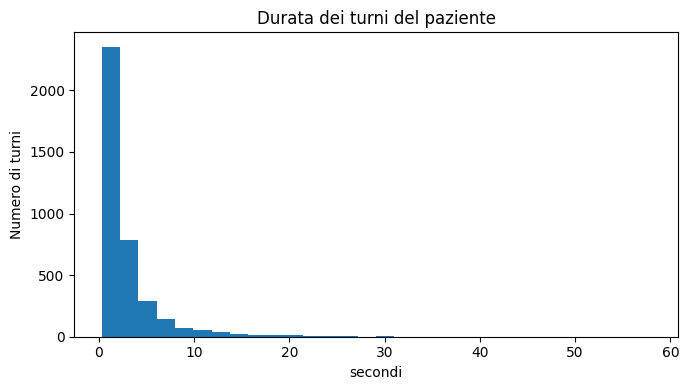

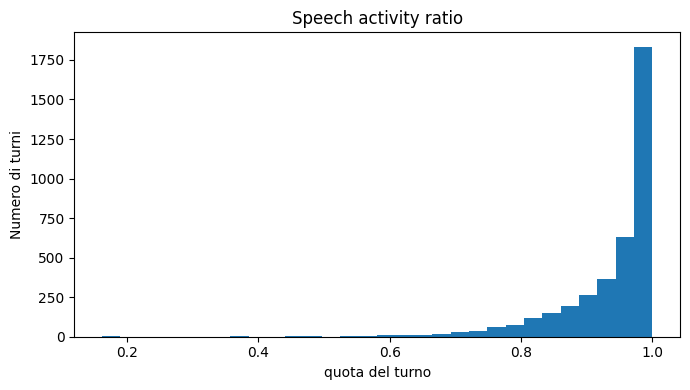

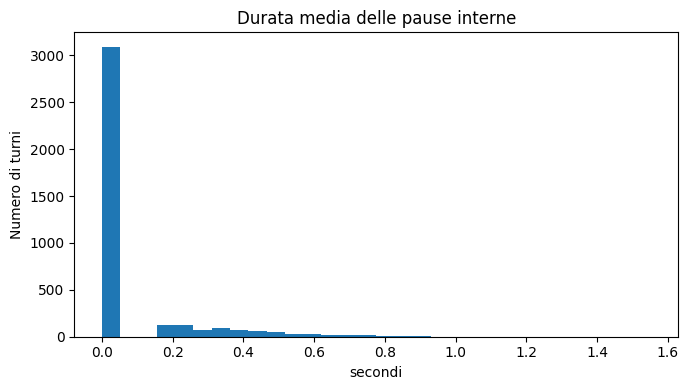

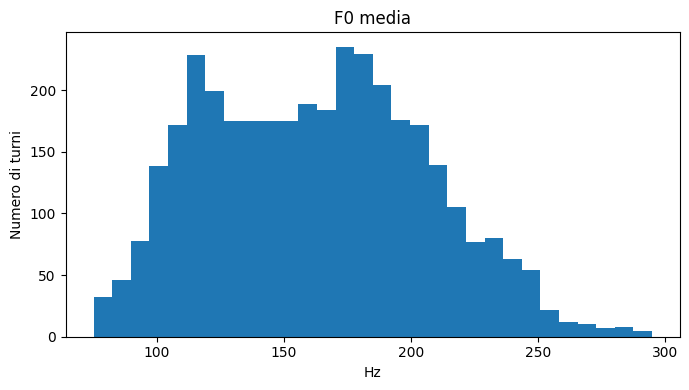

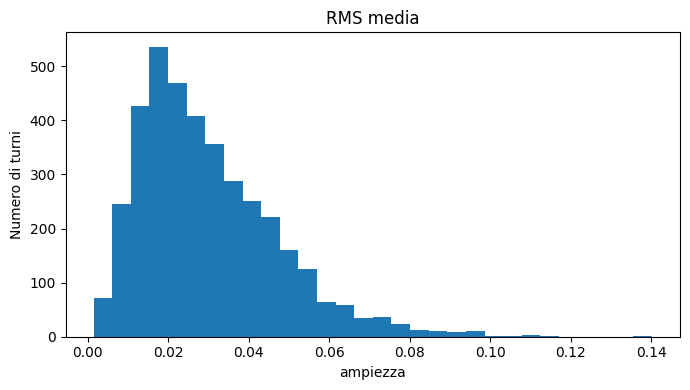

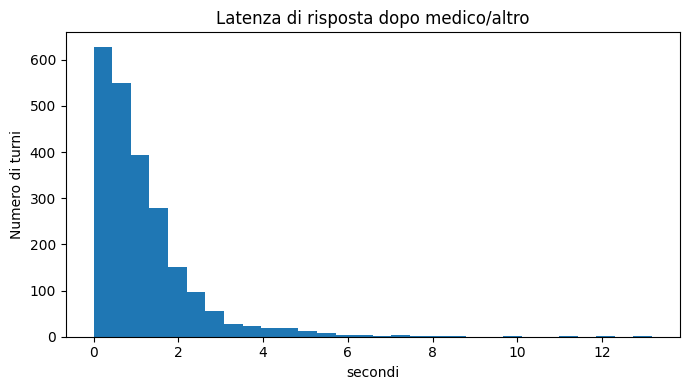

In [ ]:

plot_columns = [
    (
        "turn_duration_seconds",
        "Durata dei turni del paziente",
        "secondi",
    ),
    (
        "speech_activity_ratio",
        "Speech activity ratio",
        "quota del turno",
    ),
    (
        "internal_pause_mean_seconds",
        "Durata media delle pause interne",
        "secondi",
    ),
    (
        "f0_mean",
        "F0 media",
        "Hz",
    ),
    (
        "rms_mean",
        "RMS media",
        "ampiezza",
    ),
    (
        "response_latency_seconds",
        "Latenza di risposta dopo medico/altro",
        "secondi",
    ),
]

for column, title, xlabel in plot_columns:
    if (
        column
        not in turn_features.columns
    ):
        continue

    values = pd.to_numeric(
        turn_features[column],
        errors="coerce",
    ).dropna()

    if values.empty:
        continue

    plt.figure(
        figsize=(7, 4)
    )

    plt.hist(
        values,
        bins=30,
    )

    plt.title(
        title
    )

    plt.xlabel(
        xlabel
    )

    plt.ylabel(
        "Numero di turni"
    )

    plt.tight_layout()

    output_path = (
        OUTPUT_DIR
        / (
            "qc_"
            + column
            + ".png"
        )
    )

    plt.savefig(
        output_path,
        dpi=180,
    )
    plt.savefig("img/Pazienti.png", dpi=300, bbox_inches="tight")
    plt.show()



## 8. Aggregazione a livello paziente

Il CSV a livello turno rimane il dato principale per le future analisi di profilo.

Viene inoltre creato un riepilogo a livello paziente. Per evitare di comprimere
troppo presto l'informazione, per ciascuna feature numerica vengono salvate:

- media;
- mediana;
- deviazione standard;
- 25° percentile;
- 75° percentile.

Vengono mantenuti separatamente anche numero di turni, durata totale e numero
di registrazioni.


In [9]:

aggregation_source = (
    turn_features.copy()
)

# Escludiamo identificativi e coordinate temporali
# dall'aggregazione automatica.
exclude_from_aggregation = {
    "patient_id",
    "turn_index",
    "start_seconds",
    "end_seconds",
}

feature_cols_patient = [
    col
    for col in numeric_feature_columns
    if col not in exclude_from_aggregation
]

patient_rows = []

for patient_id, group in (
    aggregation_source
    .groupby(
        "patient_id"
    )
):
    row = {
        "patient_id": int(
            patient_id
        ),
        "n_recordings": int(
            group[
                "recording_id"
            ].nunique()
        ),
        "recordings": " | ".join(
            sorted(
                set(
                    group[
                        "recording_id"
                    ].astype(str)
                )
            )
        ),
        "n_patient_turns": int(
            len(group)
        ),
        "total_patient_turn_duration_seconds": float(
            group[
                "turn_duration_seconds"
            ].sum()
        ),
    }

    for col in feature_cols_patient:
        values = pd.to_numeric(
            group[col],
            errors="coerce",
        ).dropna()

        if values.empty:
            row[
                f"{col}__mean"
            ] = np.nan
            row[
                f"{col}__median"
            ] = np.nan
            row[
                f"{col}__std"
            ] = np.nan
            row[
                f"{col}__p25"
            ] = np.nan
            row[
                f"{col}__p75"
            ] = np.nan

            continue

        row[
            f"{col}__mean"
        ] = float(
            values.mean()
        )

        row[
            f"{col}__median"
        ] = float(
            values.median()
        )

        row[
            f"{col}__std"
        ] = float(
            values.std(
                ddof=0
            )
        )

        row[
            f"{col}__p25"
        ] = float(
            values.quantile(
                0.25
            )
        )

        row[
            f"{col}__p75"
        ] = float(
            values.quantile(
                0.75
            )
        )

    patient_rows.append(
        row
    )

patient_features = pd.DataFrame(
    patient_rows
)

PATIENT_FEATURES_CSV = (
    OUTPUT_DIR
    / "feature_acustiche_patient_level.csv"
)

patient_features.to_csv(
    PATIENT_FEATURES_CSV,
    index=False,
)

print(
    "Pazienti:",
    len(patient_features),
)

print(
    "Colonne patient-level:",
    len(patient_features.columns),
)

display(
    patient_features[
        [
            "patient_id",
            "n_recordings",
            "n_patient_turns",
            "total_patient_turn_duration_seconds",
        ]
    ].head()
)

print(
    "Salvato:",
    PATIENT_FEATURES_CSV,
)


Pazienti: 90
Colonne patient-level: 405


,patient_id,n_recordings,n_patient_turns,total_patient_turn_duration_seconds
0,1,1,34,210.735125
1,2,1,33,78.993000
2,3,1,28,123.280375
3,4,1,32,174.505000
4,10,1,22,57.444000


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\feature_acustiche_patient_level.csv


## 9. Verifica esplicita: nessuna etichetta clinica

In [11]:

forbidden_terms = [
    "dn4",
    "bpi",
    "nrs",
]

def forbidden_columns(df):
    return [
        col
        for col in df.columns
        if any(
            term in str(col).lower()
            for term
            in forbidden_terms
        )
    ]


for name, df in [
    (
        "turn_features",
        turn_features,
    ),
    (
        "patient_features",
        patient_features,
    ),
]:
    found = forbidden_columns(
        df
    )

    print(
        name,
        "-> colonne cliniche trovate:",
        found,
    )

    if found:
        raise RuntimeError(
            f"{name}: presenti colonne cliniche "
            f"non consentite in questa fase: {found}"
        )

print(
    "\nOK: il notebook 10 è indipendente "
    "da DN4, BPI e NRS."
)


turn_features -> colonne cliniche trovate: []
patient_features -> colonne cliniche trovate: []

OK: il notebook 10 è indipendente da DN4, BPI e NRS.


## 10. Riepilogo finale

In [12]:

summary = {
    "registrazioni_analizzate": int(
        turn_features[
            "recording_id"
        ].nunique()
    ),
    "pazienti_analizzati": int(
        turn_features[
            "patient_id"
        ].nunique()
    ),
    "turni_paziente_totali_timeline": int(
        len(turns_df)
    ),
    "turni_paziente_analizzati": int(
        len(turn_features)
    ),
    "durata_minima_turno_secondi": float(
        MIN_TURN_DURATION
    ),
    "merge_gap_diarizzazione_secondi": float(
        MERGE_GAP_SECONDS
    ),
    "pausa_interna_minima_secondi": float(
        MIN_INTERNAL_PAUSE_SECONDS
    ),
    "silence_top_db": float(
        SILENCE_TOP_DB
    ),
    "sample_rate_analisi": int(
        TARGET_SR
    ),
    "numero_feature_numeriche_turn_level": int(
        len(
            numeric_feature_columns
        )
    ),
}

SUMMARY_JSON = (
    OUTPUT_DIR
    / "config_feature_acustiche.json"
)

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False,
    )
)

print(
    "\nOutput principali:"
)

for path in [
    TURN_METADATA_CSV,
    TURN_FEATURES_CSV,
    PATIENT_FEATURES_CSV,
    MISSINGNESS_CSV,
    SUMMARY_JSON,
]:
    print(
        " -",
        path,
    )


{
  "registrazioni_analizzate": 92,
  "pazienti_analizzati": 90,
  "turni_paziente_totali_timeline": 4625,
  "turni_paziente_analizzati": 3825,
  "durata_minima_turno_secondi": 0.5,
  "merge_gap_diarizzazione_secondi": 0.25,
  "pausa_interna_minima_secondi": 0.15,
  "silence_top_db": 20.0,
  "sample_rate_analisi": 16000,
  "numero_feature_numeriche_turn_level": 80
}

Output principali:
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\turni_paziente_metadata.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\feature_acustiche_turn_level.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\feature_acustiche_patient_level.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\qc_missingness_feature.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\config_feature_acustiche.json
